# Three class classification 05-07: control, ff, ff_slip
I have tried collecting the normalised data for the three classes.

In [3]:
import csv
import os
import numpy as np
    

# data_path = "D:\\datasets\\tac2Slip\\severity-03-15"
# classes = ['non-contact', 'salt', 'salt-no-slip']

data_path = "D:\\datasets\\tac2Slip\\severity-05-07"
classes = ['control', 'ff_slip', 'ff']

def import_csv(file_path):
    with open(file_path, 'r') as f:
        reader = csv.reader(f)
        #skip header
        next(reader)
        data = []
        for row in reader:
            data.append([float(i) for i in row])
    data = np.array(data, dtype=np.float32)
    time = data[:, 0]
    data = data[:, 1:]
    return time, data

def restructure_data(data):
    n_samples = data.shape[0]
    n_taxels = 17
    n_channels = 3
    restructured_data = np.zeros((n_samples, 5, n_taxels, n_channels), dtype=np.float32)
    for k in range(5):
        for i in range(n_taxels):
            for j in range(n_channels):
                restructured_data[:, k, i, j] = data[:, k * n_taxels * n_channels + i * n_channels + j]
    return restructured_data

# ----------------------------- Import non-contact data ----------------------------- #
total_non_contact_data = []
c = 0
print(len(os.listdir(os.path.join(data_path, classes[c]))))
for file_path in os.listdir(os.path.join(data_path, classes[c])):
    if file_path.endswith('.csv'):
        time, data = import_csv(os.path.join(data_path, classes[c], file_path))
        total_non_contact_data.append(data)
total_non_contact_data = np.concatenate(total_non_contact_data, axis=0)
print(f"Total non-contact data shape: {total_non_contact_data.shape}")

# ----------------------- Import the slip data ----------------------- #
total_slip_data = []
c = 1
for file_path in os.listdir(os.path.join(data_path, classes[c])):
    if file_path.endswith('.csv'):
        time, data = import_csv(os.path.join(data_path, classes[c], file_path))
        total_slip_data.append(data)
total_slip_data = np.concatenate(total_slip_data, axis=0)
print(f"Total slip data shape: {total_slip_data.shape}")

# ---------------------------- Import no-slip data --------------------------- #
total_no_slip_data = []
c = 2
for file_path in os.listdir(os.path.join(data_path, classes[c])):
    if file_path.endswith('.csv'):
        time, data = import_csv(os.path.join(data_path, classes[c], file_path))
        total_no_slip_data.append(data)
total_no_slip_data = np.concatenate(total_no_slip_data, axis=0)
print(f"Total no-slip data shape: {total_no_slip_data.shape}")






10
Total non-contact data shape: (8969, 553)
Total slip data shape: (4250, 553)
Total no-slip data shape: (13530, 553)


In [9]:
# Restructure the data columns into 5 groups of 51 corresponding to 17x3 taxels
def restructure_data_ff(data, normalise=False):
    n_samples = data.shape[0]
    n_taxels = 17
    n_channels = 3
    restructured_data = np.zeros((n_samples, n_taxels, n_channels), dtype=np.float32)
    for i in range(n_taxels):
        for j in range(n_channels):
            if normalise:
                restructured_data[:, i, j] = data[:,255 + 1 * n_taxels * n_channels + i * n_channels + j]
            else:
                restructured_data[:, i, j] = data[:, 1 * n_taxels * n_channels + i * n_channels + j]
    return restructured_data


restructured_slip = restructure_data_ff(total_slip_data, normalise=True)
restructured_no_slip = restructure_data_ff(total_no_slip_data, normalise=True)
restructured_non_contact = restructure_data_ff(total_non_contact_data, normalise=True)
print(restructured_slip.shape)
print(restructured_no_slip.shape)
print(restructured_non_contact.shape)

np.set_printoptions(suppress=True, precision=4)
print(restructured_slip[0, :, :])

(4250, 17, 3)
(13530, 17, 3)
(8969, 17, 3)
[[ 0.     -0.      0.    ]
 [ 0.     -0.0033  0.    ]
 [ 0.001  -0.0048  0.    ]
 [ 0.     -0.0021  0.    ]
 [ 0.     -0.      0.    ]
 [ 0.     -0.001   0.0021]
 [ 0.0021 -0.0021  0.    ]
 [ 0.     -0.0048  0.    ]
 [ 0.     -0.005   0.0033]
 [ 0.     -0.0021  0.001 ]
 [ 0.     -0.0054  0.    ]
 [ 0.      0.      0.0033]
 [ 0.      0.      0.0021]
 [-0.      0.      0.    ]
 [ 0.     -0.0058  0.0008]
 [ 0.     -0.0042  0.    ]
 [ 0.     -0.0033  0.    ]]


In [16]:
# ----------------------------- ff classifier ----------------------------- #
ff_slip = restructured_slip[:, :, :]
ff_no_slip = restructured_no_slip[:, :, :]
ff_non_contact = restructured_non_contact[:, :, :]

print(ff_slip.shape)
print(ff_no_slip.shape)
print(ff_non_contact.shape)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
X = np.concatenate((ff_non_contact, ff_no_slip, ff_slip), axis=0)
y = np.concatenate((np.zeros(ff_non_contact.shape[0]), np.ones(ff_no_slip.shape[0]), 2*np.ones(ff_slip.shape[0])), axis=0)
print(f"X shape: {X.shape}, y shape: {y.shape}")
X = X.reshape(X.shape[0], -1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
accuracy = clf.score(X_test, y_test)
print(f'ff classifier accuracy: {accuracy * 100:.2f}%')





(4250, 17, 3)
(13530, 17, 3)
(8969, 17, 3)
X shape: (26749, 17, 3), y shape: (26749,)
ff classifier accuracy: 84.64%


In [10]:
# -------------------------- all fingers classifier -------------------------- #
X = np.concatenate((restructured_slip, restructured_no_slip, restructured_non_contact), axis=0)
y = np.concatenate((np.ones((restructured_slip.shape[0],5)), np.zeros((restructured_no_slip.shape[0],5)), 2*np.ones((restructured_non_contact.shape[0],5))), axis=0)
print(X.shape)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)


# ----------------------- individual_finger_classifiers ---------------------- #
print("RandomForestClassifier for individual fingers:")
fingers = ['ff', 'mf', 'rf', 'lf', 'th']
classifiers = {}
for i, finger in enumerate(fingers):
    X_finger = X[:, i,:, :].reshape(X.shape[0], -1)
    y_finger = y[:, i]
    X_train, X_test, y_train, y_test = train_test_split(X_finger, y_finger, test_size=0.2, random_state=42)
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)
    accuracy = clf.score(X_test, y_test)
    classifiers[finger] = clf
    print(f'{finger} classifier accuracy: {accuracy * 100:.2f}%')

# # ----------------------------- Gradient Boosting ---------------------------- #
# print("\nGradientBoostingClassifier for individual fingers:")
# from sklearn.ensemble import GradientBoostingClassifier
# fingers = ['ff', 'mf', 'rf', 'lf', 'th']
# classifiers_gb = {}
# for i, finger in enumerate(fingers):
#     X_finger = X[:, i,:, :].reshape(X.shape[0], -1)
#     y_finger = y[:, i]
#     X_train, X_test, y_train, y_test = train_test_split(X_finger, y_finger, test_size=0.2, random_state=42)
#     clf_gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
#     clf_gb.fit(X_train, y_train)
#     accuracy = clf_gb.score(X_test, y_test)
#     classifiers_gb[finger] = clf_gb
#     print(f'{finger} classifier accuracy: {accuracy * 100:.2f}%')


(75199, 5, 17, 3)
(75199, 5)
(60159, 5, 17, 3)
RandomForestClassifier for individual fingers:
ff classifier accuracy: 99.16%
mf classifier accuracy: 48.54%
rf classifier accuracy: 56.24%
lf classifier accuracy: 62.07%
th classifier accuracy: 78.03%


(26749, 51)
(26749,)


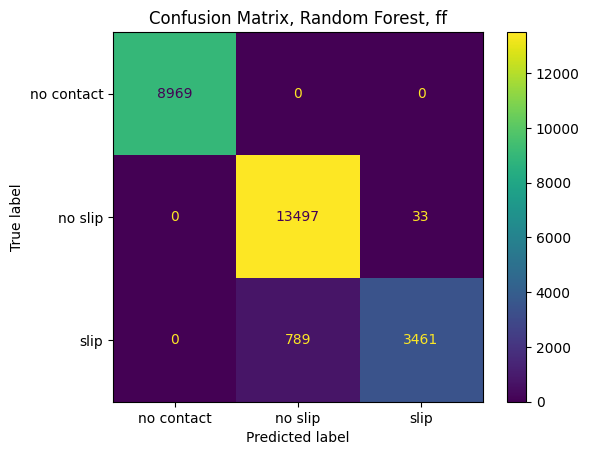

In [19]:
print(X.shape)
print(y.shape)

# ----------------------------- Confusion matrix ----------------------------- #
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = clf.predict(X)
cm = confusion_matrix(y[:], y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no contact', 'no slip', 'slip'])
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.set_title('Confusion Matrix, Random Forest, ff')
disp.plot(ax=ax)
plt.show()

In [ ]:
# Save the classifiers using something else than joblib
import joblib
for finger, clf in classifiers.items():
    joblib.dump(clf, f'{finger}_classifier.pkl')

print(type(classifiers['ff']))
    

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
